# Task 2: LSTM Model
Dedicated notebook for LSTM implementation, training, and evaluation.
ARIMA/SARIMA already completed in `eda_and_modeling.ipynb`.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

In [3]:
from data_loader import load_local_data

TICKERS = ['TSLA', 'BND', 'SPY']
data = load_local_data(TICKERS, save_dir='../data/processed')

tsla = data['TSLA']
close_prices = tsla['Close']

train = close_prices[:'2024-12-31']
test = close_prices['2025-01-01':]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} rows)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} rows)")

Train: 2015-01-02 00:00:00 to 2024-12-31 00:00:00 (2516 rows)
Test:  2025-01-02 00:00:00 to 2026-06-29 00:00:00 (372 rows)


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

In [5]:
WINDOW = 60

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW)

combined_scaled = np.concatenate([train_scaled[-WINDOW:], test_scaled])
X_test, y_test = create_sequences(combined_scaled, WINDOW)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape, X_test.shape)

(2456, 60, 1) (372, 60, 1)


In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

In [7]:
WINDOW = 60

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW)

combined_scaled = np.concatenate([train_scaled[-WINDOW:], test_scaled])
X_test, y_test = create_sequences(combined_scaled, WINDOW)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape, X_test.shape)

(2456, 60, 1) (372, 60, 1)


In [8]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\HP EliteBook\Desktop\my-projects\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 0.0061 - val_loss: 0.0073
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0017 - val_loss: 0.0077
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0016 - val_loss: 0.0048
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0015 - val_loss: 0.0042
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0014 - val_loss: 0.0033
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - loss: 0.0013 - val_loss: 0.0028
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0011 - val_loss: 0.0038
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 10/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0010 - val_loss: 0.0021
Epoch 11/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 0.0011 - val_loss: 0.0022
Epoch 12/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/

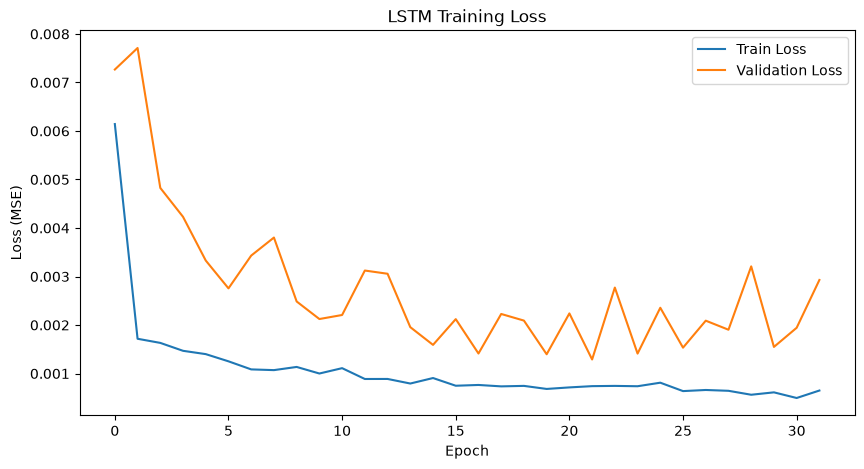

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.show()

In [11]:
lstm_pred_scaled = model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

lstm_forecast = pd.Series(lstm_pred, index=test.index[:len(lstm_pred)])

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


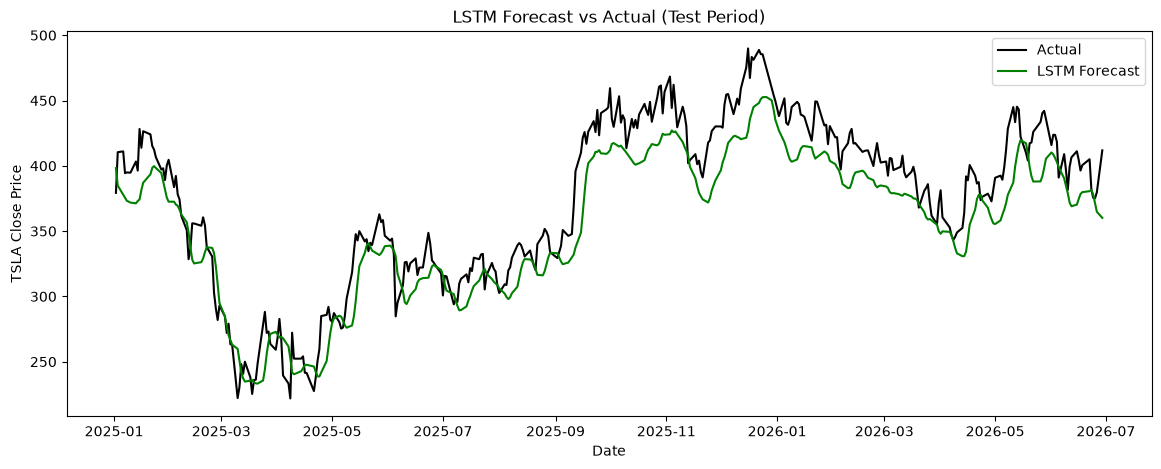

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(lstm_forecast.index, lstm_forecast, label='LSTM Forecast', color='green')
plt.legend()
plt.title('LSTM Forecast vs Actual (Test Period)')
plt.xlabel('Date')
plt.ylabel('TSLA Close Price')
plt.show()

In [13]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'MAPE (%)': round(mape, 3)}

lstm_metrics = evaluate(lstm_actual, lstm_pred, 'LSTM')
lstm_metrics

{'Model': 'LSTM',
 'MAE': 21.17,
 'RMSE': np.float64(25.412),
 'MAPE (%)': np.float64(5.564)}

In [16]:
import json

with open('../data/processed/lstm_metrics.json', 'w') as f:
    json.dump(lstm_metrics, f)

print("LSTM metrics saved — load these in eda_and_modeling.ipynb to compare with ARIMA.")

LSTM metrics saved — load these in eda_and_modeling.ipynb to compare with ARIMA.


In [15]:
import joblib

model.save('../data/processed/lstm_tsla_model.keras')
joblib.dump(scaler, '../data/processed/lstm_scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.
